Section A — Tensor creation & operations


In [2]:
import torch
import numpy as np

print("=" * 50)
print("SECTION A: Creating Tensors")
print("=" * 50)

# --- From scratch ---
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.zeros(3, 4)           # 3x4 matrix of zeros
c = torch.ones(2, 3)            # 2x3 matrix of ones
d = torch.randn(3, 3)           # 3x3 random (normal dist) — used to initialize weights
e = torch.arange(0, 10, 2)     # [0, 2, 4, 6, 8]
f = torch.linspace(0, 1, 5)    # [0, 0.25, 0.5, 0.75, 1.0]

print("randn 3x3:\n", d)
print("arange:", e)
print("linspace:", f)

# --- From numpy (zero-copy — they share memory!) ---
np_array = np.array([1.0, 2.0, 3.0])
torch_tensor = torch.from_numpy(np_array)
print("\nFrom numpy:", torch_tensor)

np_array[0] = 99  # change numpy...
print("Tensor also changed!:", torch_tensor)  # ...tensor changes too (shared memory)

# --- Dtypes matter ---
x_float32 = torch.tensor([1.0, 2.0])         # default float32
x_float64 = torch.tensor([1.0, 2.0], dtype=torch.float64)
x_int      = torch.tensor([1, 2, 3])          # int64

print("\ndtype float32:", x_float32.dtype)
print("dtype float64:", x_float64.dtype)
# Note: almost all neural network math uses float32 — it's faster on GPU

print("\n" + "=" * 50)
print("SECTION B: Shape operations (critical for debugging)")
print("=" * 50)

x = torch.randn(4, 3)      # shape: (4, 3) — 4 samples, 3 features
print("Original shape:", x.shape)  # torch.Size([4, 3])

# Reshape — change dimensions, same total elements
y = x.reshape(2, 6)         # (2, 6)   — same 12 elements
z = x.reshape(12)           # (12,)    — flatten to 1D
w = x.reshape(-1, 1)        # (12, 1)  — -1 means "figure it out"
print("Reshape (2,6):", y.shape)
print("Flatten:      ", z.shape)
print("Reshape (-1,1):", w.shape)

# Squeeze / Unsqueeze — add or remove dimensions of size 1
a = torch.randn(3)           # shape: (3,)
b = a.unsqueeze(0)           # shape: (1, 3)  — add batch dimension
c = a.unsqueeze(1)           # shape: (3, 1)  — add feature dimension
print("\nunsqueeze(0):", b.shape)
print("unsqueeze(1):", c.shape)
print("squeeze back:", b.squeeze(0).shape)  # back to (3,)

# THIS is why shapes matter in practice:
# nn.Linear(3, 4) expects input of shape (batch_size, 3)
# If you accidentally pass (3,) instead of (1, 3), you'll get an error

SECTION A: Creating Tensors
randn 3x3:
 tensor([[-0.3623, -1.1460, -0.5916],
        [-0.8443,  0.5033, -1.1736],
        [ 0.9224, -0.1579, -0.6661]])
arange: tensor([0, 2, 4, 6, 8])
linspace: tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])

From numpy: tensor([1., 2., 3.], dtype=torch.float64)
Tensor also changed!: tensor([99.,  2.,  3.], dtype=torch.float64)

dtype float32: torch.float32
dtype float64: torch.float64

SECTION B: Shape operations (critical for debugging)
Original shape: torch.Size([4, 3])
Reshape (2,6): torch.Size([2, 6])
Flatten:       torch.Size([12])
Reshape (-1,1): torch.Size([12, 1])

unsqueeze(0): torch.Size([1, 3])
unsqueeze(1): torch.Size([3, 1])
squeeze back: torch.Size([3])


Section B — The requires_grad flag and .grad


In [3]:
print("=" * 50)
print("SECTION C: requires_grad — turning on autograd")
print("=" * 50)

# A leaf tensor with requires_grad=True — PyTorch will track all operations on it
w = torch.tensor(2.0, requires_grad=True)
x = torch.tensor(3.0)             # no gradient needed for input data
b = torch.tensor(1.0, requires_grad=True)

print(f"w = {w}, requires_grad = {w.requires_grad}")
print(f"x = {x}, requires_grad = {x.requires_grad}")

# Forward pass
z = w * x + b      # z = 2*3 + 1 = 7
print(f"\nz = w*x + b = {z.item()}")
print(f"z.grad_fn = {z.grad_fn}")   # MulBackward — remembers how z was made

loss = (z - 5) ** 2   # pretend our target is 5, loss = (7-5)^2 = 4
print(f"loss = (z-5)^2 = {loss.item()}")
print(f"loss.grad_fn = {loss.grad_fn}")   # PowBackward

# Backward pass — chain rule fires
loss.backward()

# Gradients are now stored in .grad
print(f"\nAfter loss.backward():")
print(f"  w.grad = {w.grad}")    # ∂loss/∂w = 2*(z-5)*x = 2*(7-5)*3 = 12
print(f"  b.grad = {b.grad}")    # ∂loss/∂b = 2*(z-5)*1 = 2*(7-5)*1 = 4

# Let's verify manually:
# loss = (w*x + b - 5)^2
# ∂loss/∂w = 2*(w*x + b - 5) * x = 2*(7-5)*3 = 12  ✓
# ∂loss/∂b = 2*(w*x + b - 5) * 1 = 2*(7-5)*1 = 4   ✓
print("\nManual check: ∂loss/∂w = 2*(7-5)*3 =", 2*(7-5)*3, "✓")
print("Manual check: ∂loss/∂b = 2*(7-5)*1 =", 2*(7-5)*1, "✓")

SECTION C: requires_grad — turning on autograd
w = 2.0, requires_grad = True
x = 3.0, requires_grad = False

z = w*x + b = 7.0
z.grad_fn = <AddBackward0 object at 0x7a767a1b31c0>
loss = (z-5)^2 = 4.0
loss.grad_fn = <PowBackward0 object at 0x7a767a1b31c0>

After loss.backward():
  w.grad = 12.0
  b.grad = 4.0

Manual check: ∂loss/∂w = 2*(7-5)*3 = 12 ✓
Manual check: ∂loss/∂b = 2*(7-5)*1 = 4 ✓


Section C — Gradient accumulation gotcha (very important)


In [4]:
print("=" * 50)
print("SECTION D: The gradient accumulation GOTCHA")
print("=" * 50)

w = torch.tensor(2.0, requires_grad=True)
x = torch.tensor(3.0)

# Run the backward pass 3 times WITHOUT zeroing gradients
for i in range(3):
    loss = (w * x) ** 2
    loss.backward()
    print(f"Pass {i+1}: w.grad = {w.grad}")   # Keeps ADDING up!

print("\nThis is why optimizer.zero_grad() is step 3 in every training loop!")
print("If you forget it, gradients from previous batches accumulate → wrong updates\n")

# Correct way: zero before each backward
w = torch.tensor(2.0, requires_grad=True)
for i in range(3):
    if w.grad is not None:
        w.grad.zero_()         # zero the gradient IN-PLACE (the _ suffix = in-place)
    loss = (w * x) ** 2
    loss.backward()
    print(f"Pass {i+1} (zeroed): w.grad = {w.grad}")   # Always correct value

SECTION D: The gradient accumulation GOTCHA
Pass 1: w.grad = 36.0
Pass 2: w.grad = 72.0
Pass 3: w.grad = 108.0

This is why optimizer.zero_grad() is step 3 in every training loop!
If you forget it, gradients from previous batches accumulate → wrong updates

Pass 1 (zeroed): w.grad = 36.0
Pass 2 (zeroed): w.grad = 36.0
Pass 3 (zeroed): w.grad = 36.0


Section D — no_grad context: inference mode


In [5]:
print("=" * 50)
print("SECTION E: torch.no_grad() — use during inference")
print("=" * 50)

w = torch.tensor(2.0, requires_grad=True)
x = torch.tensor(3.0)

# During training: track gradients
z_train = w * x
print(f"Training mode — z.requires_grad: {z_train.requires_grad}")
print(f"Training mode — z.grad_fn: {z_train.grad_fn}")

# During inference: don't track (saves memory + is faster)
with torch.no_grad():
    z_infer = w * x
    print(f"\nInference mode — z.requires_grad: {z_infer.requires_grad}")
    print(f"Inference mode — z.grad_fn: {z_infer.grad_fn}")

# Also use .detach() to pull a tensor out of the graph
z_detached = z_train.detach()
print(f"\nDetached — requires_grad: {z_detached.requires_grad}")
# Common use: when you want to plot loss values (you don't need the graph then)

SECTION E: torch.no_grad() — use during inference
Training mode — z.requires_grad: True
Training mode — z.grad_fn: <MulBackward0 object at 0x7a767a1f50c0>

Inference mode — z.requires_grad: False
Inference mode — z.grad_fn: None

Detached — requires_grad: False


Section E — Manual gradient descent from scratch


SECTION F: Manual gradient descent — no optimizer, no nn.Module
Starting: w=0.000, b=0.000
Target:   w=3.000, b=2.000

Step   0 | loss=7.3212 | w=0.214 | b=0.409
Step  20 | loss=0.1800 | w=2.324 | b=2.024
Step  40 | loss=0.0406 | w=2.781 | b=2.043
Step  60 | loss=0.0341 | w=2.879 | b=2.043
Step  80 | loss=0.0338 | w=2.901 | b=2.043

Final: w=2.905 (target 3.0) | b=2.043 (target 2.0)


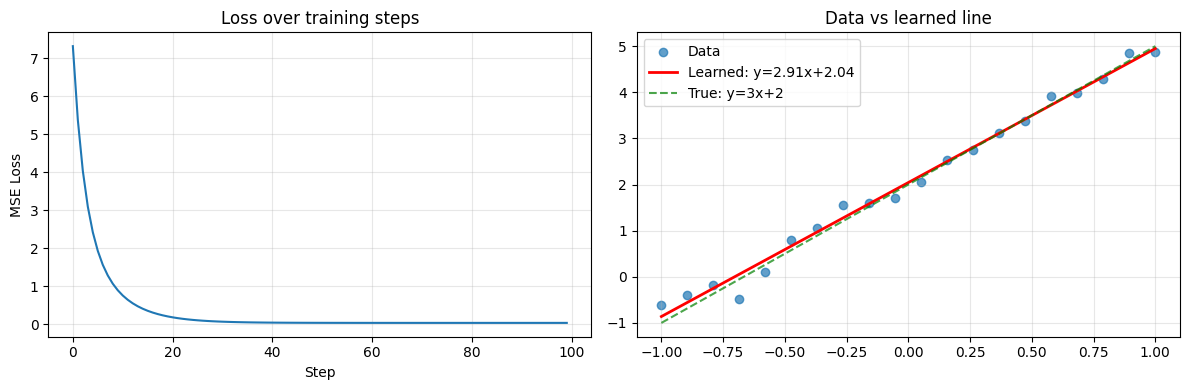

In [6]:
import matplotlib.pyplot as plt

print("=" * 50)
print("SECTION F: Manual gradient descent — no optimizer, no nn.Module")
print("=" * 50)

# Task: fit y = 3x + 2 using gradient descent
# We'll find w and b from scratch using only autograd

torch.manual_seed(42)

# Real data
X_data = torch.linspace(-1, 1, 20)
Y_data = 3 * X_data + 2 + torch.randn(20) * 0.2  # y = 3x + 2 + noise

# Our learnable parameters
w = torch.tensor(0.0, requires_grad=True)   # start at 0, true is 3
b = torch.tensor(0.0, requires_grad=True)   # start at 0, true is 2

lr = 0.1
losses = []

print(f"Starting: w={w.item():.3f}, b={b.item():.3f}")
print(f"Target:   w=3.000, b=2.000\n")

for step in range(100):
    # 1. Forward pass
    y_pred = w * X_data + b
    loss = ((y_pred - Y_data) ** 2).mean()   # MSE loss

    # 2. Backward pass
    loss.backward()

    # 3. Manually update weights (this is what optimizers do internally)
    with torch.no_grad():         # IMPORTANT: don't track the update itself
        w -= lr * w.grad
        b -= lr * b.grad

    # 4. Zero gradients
    w.grad.zero_()
    b.grad.zero_()

    losses.append(loss.item())

    if step % 20 == 0:
        print(f"Step {step:3d} | loss={loss.item():.4f} | w={w.item():.3f} | b={b.item():.3f}")

print(f"\nFinal: w={w.item():.3f} (target 3.0) | b={b.item():.3f} (target 2.0)")

# Plot loss curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses)
ax1.set_title("Loss over training steps")
ax1.set_xlabel("Step")
ax1.set_ylabel("MSE Loss")
ax1.grid(True, alpha=0.3)

ax2.scatter(X_data.detach(), Y_data.detach(), label='Data', alpha=0.7)
x_line = torch.linspace(-1, 1, 100)
with torch.no_grad():
    y_line = w * x_line + b
ax2.plot(x_line, y_line.detach(), 'r-', linewidth=2, label=f'Learned: y={w.item():.2f}x+{b.item():.2f}')
ax2.plot(x_line, 3*x_line + 2, 'g--', linewidth=1.5, label='True: y=3x+2', alpha=0.7)
ax2.legend()
ax2.set_title("Data vs learned line")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Section F — GPU tensors (know this for interviews)


In [9]:
import torch

print("=" * 50)
print("SECTION G: GPU tensors")
print("=" * 50)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create tensor directly on GPU
x_gpu = torch.randn(1000, 1000, device=device)
w_gpu = torch.randn(1000, 500, device=device)

# Matrix multiply
result = torch.matmul(x_gpu, w_gpu)
print(f"Result shape: {result.shape}, device: {result.device}")

# Move tensors between CPU and GPU
x_cpu = torch.randn(3, 3)
x_gpu = x_cpu.to(device)
x_back = x_gpu.cpu()

# Device-agnostic code
model_weights = torch.randn(10, 5).to(device)
input_data = torch.randn(1, 10).to(device)

# Correct multiplication
output = torch.matmul(input_data, model_weights)

print(f"\nDevice-agnostic forward pass output shape: {output.shape}")

SECTION G: GPU tensors
Using device: cpu
Result shape: torch.Size([1000, 500]), device: cpu

Device-agnostic forward pass output shape: torch.Size([1, 5])


Section G — Important tensor operations cheatsheet


In [10]:
print("=" * 50)
print("SECTION H: Operations you'll use every day")
print("=" * 50)

A = torch.randn(4, 3)
B = torch.randn(3, 5)

# Matrix operations
print("Matrix multiply A(4,3) @ B(3,5) =", torch.matmul(A, B).shape)   # (4, 5)
print("Element-wise A*A =", (A * A).shape)          # (4, 3) — same shape

# Reductions
print("\nMean (all):", A.mean().item())
print("Mean (per col):", A.mean(dim=0).shape)     # (3,) — average each column
print("Mean (per row):", A.mean(dim=1).shape)     # (4,) — average each row
print("Sum:", A.sum().item())
print("Max value:", A.max().item())
print("Argmax:", A.argmax().item())             # index of max element

# Stacking / concatenation
x = torch.randn(3, 4)
y = torch.randn(3, 4)
print("\ncat dim=0:", torch.cat([x, y], dim=0).shape)   # (6, 4) — stack rows
print("cat dim=1:", torch.cat([x, y], dim=1).shape)   # (3, 8) — stack cols
print("stack:    ", torch.stack([x, y], dim=0).shape)  # (2, 3, 4) — new dimension

# Softmax — converts logits to probabilities (used in every classifier)
logits = torch.tensor([2.0, 1.0, 0.1])
probs = torch.softmax(logits, dim=0)
print("\nLogits:", logits)
print("Softmax:", probs.round(decimals=3))
print("Sum of probs:", probs.sum().item())   # always 1.0

SECTION H: Operations you'll use every day
Matrix multiply A(4,3) @ B(3,5) = torch.Size([4, 5])
Element-wise A*A = torch.Size([4, 3])

Mean (all): -0.3947010934352875
Mean (per col): torch.Size([3])
Mean (per row): torch.Size([4])
Sum: -4.73641300201416
Max value: 1.573907494544983
Argmax: 8

cat dim=0: torch.Size([6, 4])
cat dim=1: torch.Size([3, 8])
stack:     torch.Size([2, 3, 4])

Logits: tensor([2.0000, 1.0000, 0.1000])
Softmax: tensor([0.6590, 0.2420, 0.0990])
Sum of probs: 1.0000001192092896


🎨 Part 4: Visualizing Autograd in Action (30 min)


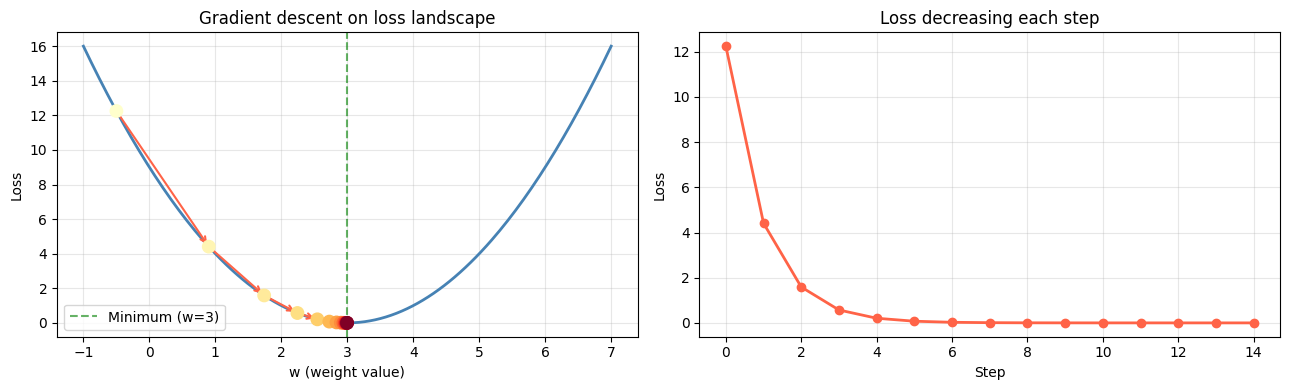

Final w: 2.9973 (target: 3.0)
Each arrow = one gradient step pushing w toward the minimum


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Visualize the loss landscape and gradient descent path
# This builds the intuition for WHY gradients work

def loss_fn(w):
    # Simple bowl-shaped loss: L(w) = (w - 3)^2
    return (w - 3) ** 2

# The landscape
w_range = np.linspace(-1, 7, 200)
loss_range = [(w - 3)**2 for w in w_range]

# Gradient descent path
w = torch.tensor(-0.5, requires_grad=True)
lr = 0.2
path_w, path_loss = [], []

for step in range(15):
    l = loss_fn(w)
    path_w.append(w.item())
    path_loss.append(l.item())

    l.backward()

    with torch.no_grad():
        w -= lr * w.grad
    w.grad.zero_()

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Loss landscape
ax1.plot(w_range, loss_range, 'steelblue', linewidth=2)
ax1.scatter(path_w, path_loss, c=range(len(path_w)),
            cmap='YlOrRd', s=80, zorder=5)
for i in range(len(path_w)-1):
    ax1.annotate('', xy=(path_w[i+1], path_loss[i+1]),
                 xytext=(path_w[i], path_loss[i]),
                 arrowprops=dict(arrowstyle='->', color='tomato', lw=1.5))
ax1.axvline(x=3, color='green', linestyle='--', alpha=0.6, label='Minimum (w=3)')
ax1.set_xlabel('w (weight value)')
ax1.set_ylabel('Loss')
ax1.set_title('Gradient descent on loss landscape')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss over steps
ax2.plot(path_loss, 'o-', color='tomato', linewidth=2, markersize=6)
ax2.set_xlabel('Step')
ax2.set_ylabel('Loss')
ax2.set_title('Loss decreasing each step')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final w: {path_w[-1]:.4f} (target: 3.0)")
print("Each arrow = one gradient step pushing w toward the minimum")